In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
import pandas as pd
import numpy as np
import seaborn as sns
import sklearn.preprocessing as sp
import pickle
import matplotlib.pyplot as plt
import scienceplots
import scipy
import os
import time
from datetime import date
from scipy.stats import ttest_ind
today = date.today()

from utils import readSingleCellData_sqlalch, handle_nans, extract_cpfeature_names,\
    find_correlation, check_feature_similarity_dendrogram

In [2]:
import seaborn as sns
print(sns.__version__)
import sklearn
print(sklearn.__version__)

0.12.2
1.0.2


## Read Data

In [2]:
%%time

home_path="/home/ubuntu/" # ec2
home_path="/home/jupyter-mhaghigh@broadinst-ee45a/" #dgx

rootDir=home_path+"bucket/projects/2016_08_01_RadialMitochondriaDistribution_donna/"

compartments = ['mito','actin','dna']
# the directory data and images are stored in
dataDir=rootDir+"workspace/singleCellData/"
imDir=rootDir+"Mito_Morphology_input/images/"
sql_data= rootDir+"workspace/backend/Mito_Morphology_input"

df_1_0_0=pd.read_pickle(dataDir+'single_cell_with_annot.pkl', compression='infer')
subject_list=os.listdir(sql_data)
sc_df_ls=[]
compartments = ["Cells","Cytoplasm","Nuclei"]
for si in subject_list:
    fileName = sql_data+'/'+si+'/'+si+'.sqlite'
    sc_df = readSingleCellData_sqlalch(fileName,compartments);
    sc_df['subject']=si
    sc_df_ls.append(sc_df)

df_new = pd.concat(sc_df_ls,ignore_index=True)

df_1_0=pd.read_pickle(dataDir+'single_cell_with_annot_allFeatures.pkl', compression='infer')
df_1_0 = df_1_0.interpolate()

common_subjects = list(set(df_new['subject'].unique()) & set(df_1_0['subject'].unique()))
df_1 = df_new[df_new['subject'].isin(common_subjects)]


df_1 = pd.merge(df_1, df_1_0[['subject','label']].drop_duplicates(), on='subject',how='left')
disease_labels=pd.read_excel(home_path+"bucket/projects/2016_08_01_RadialMitochondriaDistribution_donna/\
workspace/metadata/patient_labels_updatedSept302025.xlsx")
disease_labels=disease_labels.rename(columns={"ID": "subject"})
disease_labels["subject"]=disease_labels["subject"].astype(str)

df_1 = pd.merge(df_1,disease_labels,on=["subject"],how="left")

df_1['subject'] = df_1['subject'].replace(['370E','370F','370H'],'370');

df_1.loc[df_1['subject']=='272','label']='Control'
df_1.loc[df_1['subject']=='MCL004','label']='SZA'
##################### Clean and shrink features
(
    cp_features,
    cp_features_analysis_0,
) = extract_cpfeature_names(df_1)
df_1, cp_features_analysis = handle_nans(
    df_1,
    cp_features_analysis_0,
    thrsh_null_ratio=0.05,
    thrsh_std=0.001,
    fill_na_method="drop-rows",
)
    

############### remove cells on the border
borderLength=200

im_width = df_1['Width_Mito'].values[0] #1388
im_height = df_1['Height_Mito'].values[0] #1040
print(df_1.shape)
df_1_centCells=df_1.loc[~((df_1['Nuclei_Location_Center_X']>(im_width-borderLength)) | (df_1['Nuclei_Location_Center_X']<(borderLength))\
                        | (df_1['Nuclei_Location_Center_Y']>(im_height-borderLength)) | (df_1['Nuclei_Location_Center_Y']<(borderLength))),:].reset_index(drop=True)

print("After border cell removal: ",df_1_centCells.shape)

df_1_centCells['Cells2Nuclei_MajorAxisLengthRatio']=df_1_centCells['Cells_AreaShape_MajorAxisLength']/df_1_centCells['Nuclei_AreaShape_MajorAxisLength']
df_1_centCells['Cells2Nuclei_AreaShapeRatio']=df_1_centCells['Cells_AreaShape_Area']/df_1_centCells['Nuclei_AreaShape_Area']
df_1_centCells = df_1_centCells[df_1_centCells['Cells2Nuclei_MajorAxisLengthRatio']>2].reset_index(drop=True)
df_1_centCells = df_1_centCells[df_1_centCells['Cells2Nuclei_AreaShapeRatio']>5].reset_index(drop=True)

print("After cell seg pron cells removal: ",df_1_centCells.shape)

df_1= df_1_centCells[(df_1_centCells['Cells_Intensity_MeanIntensity_Actin']<.5) &\
                                (df_1_centCells['Nuclei_Intensity_MeanIntensity_Actin']<.55)].reset_index(drop=True)

print("After intensity artifact cells removal: ",df_1.shape)


df_1, cp_features_analysis = handle_nans(
    df_1,
    cp_features_analysis,
    thrsh_null_ratio=0.05,
    thrsh_std=0.001,
    fill_na_method="drop-rows",
)


scaler = sp.StandardScaler()
s0=scaler.fit(df_1[cp_features_analysis])
df_1['label'] = df_1['label'].replace('MDD or Dep','MDD')
df_1_scaled=df_1.copy()

df_1_scaled[cp_features_analysis]=s0.transform(df_1[cp_features_analysis])

similar_fs_2remove=find_correlation(df_1_scaled[cp_features_analysis],\
                                                 threshold=0.7,remove_negative=True)

cp_features_collcorr=list(set(cp_features_analysis) - set(similar_fs_2remove))

# df_1['label'] = df_1['label'].replace('MDD or Dep','MDD')
# df_1_scaled['label'] = df_1_scaled['label'].replace('MDD or Dep','MDD')

cp_features: 2185
cols2remove_manyNulls []
cols2remove_lowVars ['Cells_Texture_DifferenceVariance_Mito_5_00_256', 'Cytoplasm_Texture_DifferenceVariance_Actin_3_00_256', 'Nuclei_Texture_DifferenceVariance_Mito_5_01_256', 'Nuclei_Texture_DifferenceVariance_DNA_10_03_256', 'Nuclei_Texture_DifferenceVariance_Actin_5_03_256', 'Cells_Texture_DifferenceVariance_Actin_3_02_256', 'Cytoplasm_Texture_DifferenceVariance_Mito_5_00_256', 'Cytoplasm_Texture_DifferenceVariance_Mito_3_01_256', 'Cytoplasm_Texture_DifferenceVariance_Actin_5_03_256', 'Nuclei_Texture_DifferenceVariance_DNA_10_02_256', 'Cytoplasm_Texture_DifferenceVariance_Mito_5_01_256', 'Cells_Texture_DifferenceVariance_Actin_10_01_256', 'Nuclei_Texture_DifferenceVariance_Actin_3_03_256', 'Nuclei_Texture_DifferenceVariance_Actin_10_01_256', 'Cells_Texture_DifferenceVariance_Actin_3_01_256', 'Nuclei_Texture_DifferenceVariance_DNA_10_00_256', 'Cells_Texture_DifferenceVariance_Actin_3_00_256', 'Cytoplasm_Texture_DifferenceVariance_Mito_5_02_

In [6]:
# df_1.columns

In [8]:
# df_1_scaled.head()
# df_1.loc[df_1['label'].isin('Control'),'subject']

## Correlation of 12of12 feature with 16of16 features

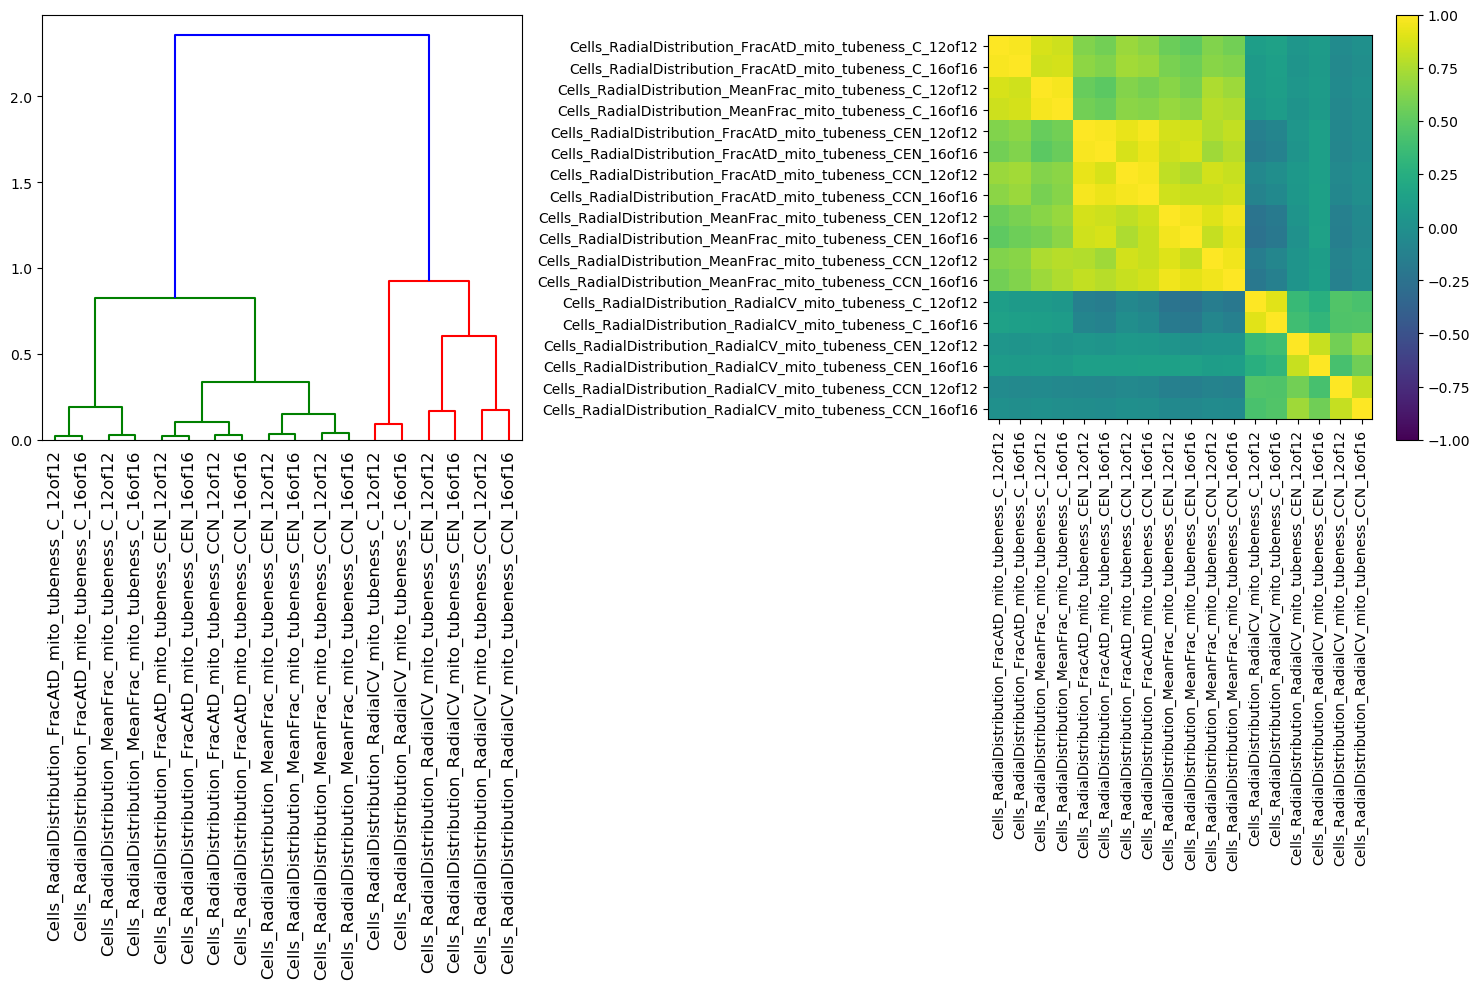

In [3]:
fs_mito_tubeness = df_1_scaled.columns[
        df_1_scaled.columns.str.contains("12of12|16of16")
    ].tolist()
# fs_mito_tubeness
dendf=check_feature_similarity_dendrogram(df_1_scaled, fs_mito_tubeness,(15, 10))

## Cluster features and select median feature from each cluster
- Supplementary Figure 5.

45


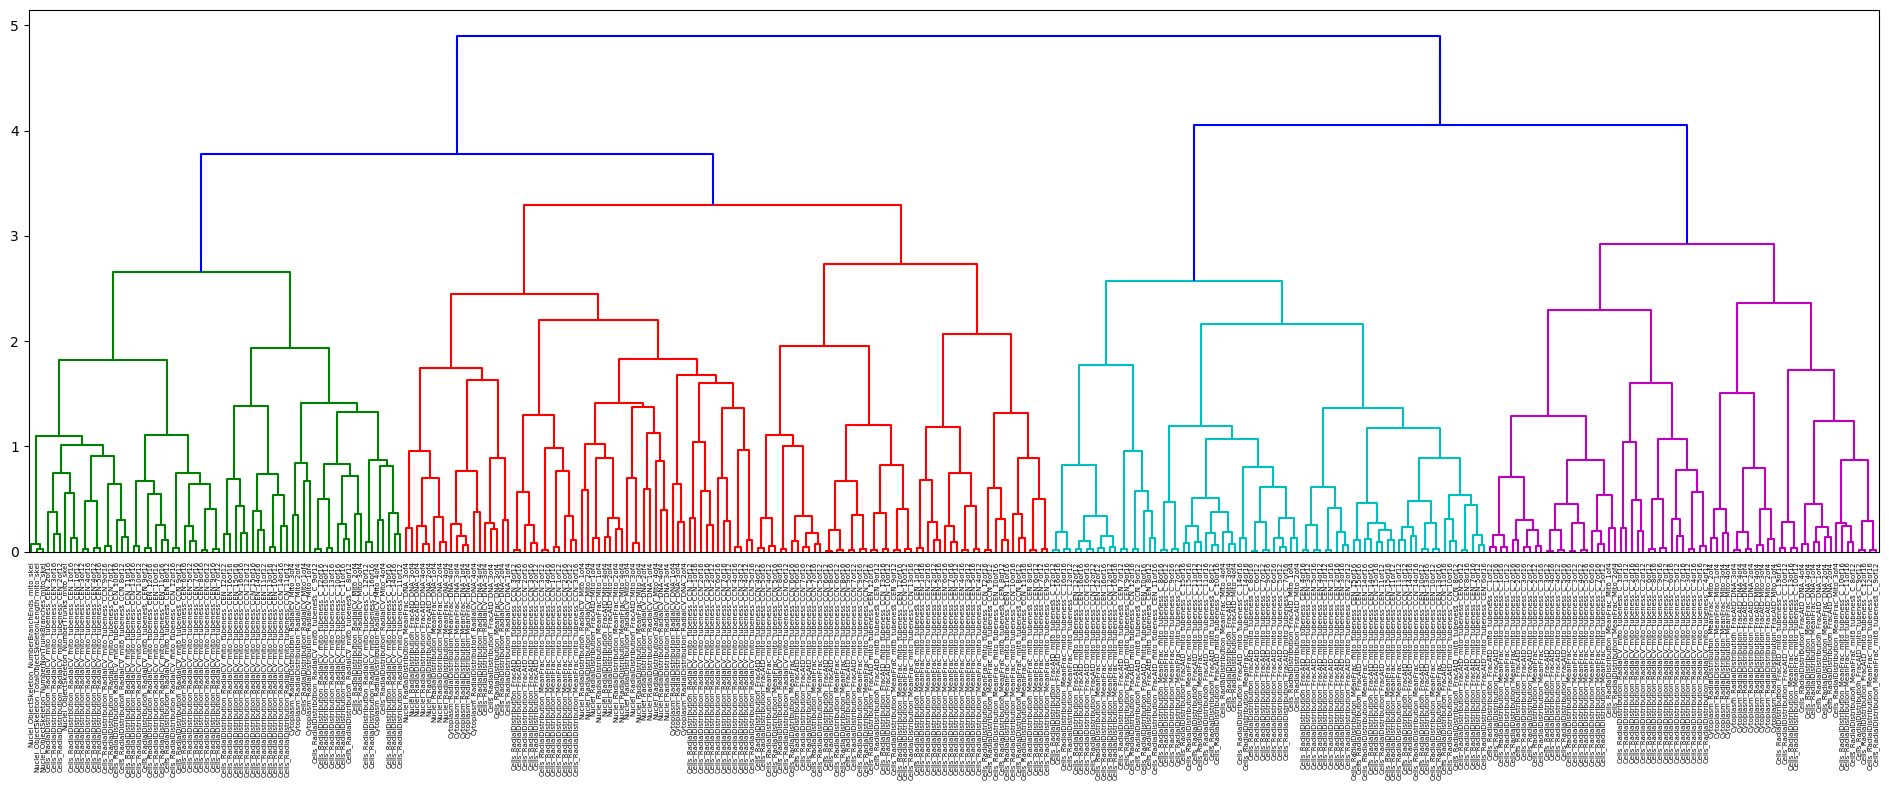

In [4]:
# from scipy.stats import spearmanr
fig, ax = plt.subplots(1, 1, figsize=(19, 8))
# corr = spearmanr(data4DM).correlation
# data4DM_BP=df_1_scaled[(df_1_scaled['label']=='Control')|(df_1_scaled['label']==d)]
# df_1_scaled[cp_features_analysis_0] = df_1_scaled[cp_features_analysis_0].interpolate()
# mito_features = [f for f in cp_features_analysis if "mito_" in f or "Mito" in f]
mito_features = [f for f in cp_features_analysis if ("mito_" in f or "RadialDistribution" in f) and ("Actin" not in f) and ("Correlation" not in f)]
corr=df_1_scaled[mito_features].corr().values
from scipy.cluster import hierarchy
from scipy.spatial.distance import squareform
import hdmedians as hd
import matplotlib.ticker as ticker
ticker.Locator.MAXTICKS = 10000  # or some large number


# Ensure the correlation matrix is symmetric
corr = (corr + corr.T) / 2
np.fill_diagonal(corr, 1)

# We convert the correlation matrix to a distance matrix before performing
# hierarchical clustering using Ward's linkage.
distance_matrix = 1 - np.abs(corr)

dist_linkage = hierarchy.ward(squareform(distance_matrix))
dendro = hierarchy.dendrogram(
    dist_linkage, labels=mito_features, ax=ax, leaf_rotation=90
)
dendro_idx = np.arange(0, len(dendro["ivl"]))
plt.tight_layout() 

############################ Based on y-ax threshold form groups
from collections import defaultdict
y_ax_thsh=1.1
cluster_ids = hierarchy.fcluster(dist_linkage, y_ax_thsh, criterion="distance")
cluster_id_to_feature_ids = defaultdict(list)
for idx, cluster_id in enumerate(cluster_ids):
    cluster_id_to_feature_ids[cluster_id].append(idx)
    
cluster_rep_feats=[]
for v in cluster_id_to_feature_ids.values():
    ps_arr=df_1_scaled[df_1_scaled[mito_features].columns[v]].T.values
    gms=hd.medoid(ps_arr,axis=0)
    gm_sample_ind=np.where(np.sum((ps_arr-gms),axis=1)==0)[0]   
    cluster_rep_feats.append(df_1_scaled[mito_features].columns[v][gm_sample_ind].tolist()[0])
            
# selected_features = [v[(int(len(v)/2))-1] for v in cluster_id_to_feature_ids.values()]

# cluster_rep_feats = df_1_scaled[filteredbyMoFnamesMito].columns[selected_features]
print(len(cluster_rep_feats))
fig.savefig("../results/dendrogram_mito.pdf", bbox_inches="tight")

In [14]:
len(cluster_rep_feats)

45

In [100]:
# len(cluster_rep_feats)
cluster_rep_feats

['Nuclei_RadialDistribution_MeanFrac_DNA_2of4',
 'Cells_RadialDistribution_RadialCV_DNA_3of4',
 'Cytoplasm_RadialDistribution_RadialCV_Mito_2of4',
 'Cells_RadialDistribution_RadialCV_mito_tubeness_C_2of12',
 'Cells_RadialDistribution_FracAtD_mito_tubeness_CEN_3of12',
 'Cells_RadialDistribution_MeanFrac_mito_tubeness_CEN_8of12',
 'Cells_RadialDistribution_RadialCV_mito_tubeness_CEN_3of12',
 'Cells_RadialDistribution_FracAtD_mito_tubeness_CCN_9of12',
 'Cells_RadialDistribution_RadialCV_mito_tubeness_CEN_10of12',
 'Cells_RadialDistribution_MeanFrac_mito_tubeness_CEN_6of12',
 'Cells_RadialDistribution_FracAtD_mito_tubeness_CCN_16of16',
 'Nuclei_RadialDistribution_MeanFrac_Mito_3of4',
 'Cells_RadialDistribution_MeanFrac_mito_tubeness_CEN_10of12',
 'Cells_RadialDistribution_MeanFrac_mito_tubeness_C_4of12',
 'Cells_RadialDistribution_MeanFrac_mito_tubeness_CEN_2of12',
 'Cells_RadialDistribution_FracAtD_mito_tubeness_CCN_2of12',
 'Cells_RadialDistribution_MeanFrac_mito_tubeness_CCN_2of12',
 'C

## VIF for the cluster_rep_feats

In [82]:
vif_data = pd.DataFrame()
# vif_data["feature"] = cluster_rep_feats
vif_data["feature"] =cluster_rep_feats#cluster_rep_feats.tolist()+["Cells_RadialDistribution_MeanFrac_mito_tubeness_16of16"]
  
# calculating VIF for each feature
vif_data["VIF"] = [variance_inflation_factor(df_1_scaled[cluster_rep_feats].values, i)
                          for i in range(len(cluster_rep_feats))]
# vif_data

# pd.set_option('display.width', 10)
# with pd.option_context('display.max_rows', None,
#                        'display.max_columns', None,
#                        'display.precision', 3,
#                        ):
# print(vif_data.to_markdown())
vif_data.sort_values(by='VIF')

,feature,VIF
37,Cytoplasm_RadialDistribution_RadialCV_DNA_2of4,1.036113
22,Nuclei_RadialDistribution_RadialCV_DNA_2of4,1.049828
33,Cells_RadialDistribution_RadialCV_mito_tubenes...,1.112135
36,Cells_RadialDistribution_RadialCV_mito_tubenes...,1.144318
41,Cells_RadialDistribution_RadialCV_mito_tubenes...,1.158371
28,Cells_RadialDistribution_RadialCV_mito_tubenes...,1.179038
3,Cells_RadialDistribution_RadialCV_mito_tubenes...,1.268994
2,Cytoplasm_RadialDistribution_RadialCV_Mito_2of4,1.276843
11,Nuclei_RadialDistribution_MeanFrac_Mito_3of4,1.280937
26,Nuclei_RadialDistribution_RadialCV_DNA_4of4,1.354545


## Checking feature importance and the permutation importance

## LogisticRegression (set dist percentile as set representation)

In [6]:
# q_auc_df.groupby(['group','Q']).size()
len(mito_features)

326

In [7]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import f1_score,balanced_accuracy_score,roc_auc_score
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedGroupKFold, StratifiedKFold
from sklearn.linear_model import LogisticRegression
import random

# Set random seeds for reproducibility
random.seed(1)
np.random.seed(1)
mito_features = [f for f in cp_features_analysis if ("mito_" in f or "RadialDistribution" in f) and ("Actin" not in f) and ("Correlation" not in f)]
feat = mito_features.copy()

df_1_ = df_1_scaled.copy()

disLabels=['psychosis','BP', 'SZ', 'SZA','MDD']
table_pval_ls=[]

abundance_df_all_ls=[]
mi_df_ls=[]
p_val_ls=[]
n_permutations = 10
for d in disLabels:
    qi=0.5
    sgkf = StratifiedKFold(n_splits=10)
    if d=='psychosis':
        data4DM_BP=df_1_[df_1_['label'].isin(['Control','BP', 'SZ', 'SZA'])].reset_index(drop=True)
        data4DM_BP.loc[data4DM_BP['label'].isin(['BP', 'SZ', 'SZA']),'label']='psychosis'
    else:
        data4DM_BP=df_1_[(df_1_['label']=='Control')|(df_1_['label']==d)].reset_index(drop=True)

    data4DM_BP = data4DM_BP.groupby(['subject','label'])[feat].quantile(qi).reset_index()

    data4DM = data4DM_BP.loc[:,feat];

    le2 = sp.LabelEncoder()

    data4DM_BP['bin_label']=data4DM_BP['label'].replace(['Control', d],[0, 1], inplace=False)
    labels=data4DM_BP['bin_label'].values

    X,y=data4DM.values,labels
    mi = mutual_info_classif(X, y)
    mi_df = pd.DataFrame({'Feature': feat, 'Mutual_Info': mi}).sort_values('Mutual_Info', ascending=False)[0:10]
    mi_df['Label']=d
    mi_df_ls.append(mi_df);
    clf_ls=[]
    scores=[]
    test_ind=[]
    auc_scores=[]
    null_fold_aucs = []
    combined_null_aucs=[]
    for train_index, test_index in sgkf.split(X, y):
    #         print("TRAIN:", train_index, "TEST:", test_index)
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]
    
        clf = LogisticRegression(solver='liblinear',class_weight='balanced')
    #     clf = RandomForestClassifier(n_estimators=10,max_features=data4DM.shape[1])
        clf.fit(X_train, y_train)  

        data4DM_BP.loc[test_index,'cell_scores'] = clf.predict_proba(X_test)[:, 1]

        scores.append(balanced_accuracy_score(y_test, clf.predict(X_test)))
        auc_scores.append(roc_auc_score(y_test, clf.predict_proba(X_test)[:, 1]))
        clf_ls.append(clf)
        test_ind.append(test_index)

        # Null distribution for this fold
        fold_null_aucs_fold = []
        for _ in range(n_permutations):
            shuffled_y_train = np.random.permutation(y_train)
            clf.fit(X_train, shuffled_y_train)
            fold_null_aucs_fold.append(roc_auc_score(y_test, clf.predict_proba(X_test)[:, 1]))

        null_fold_aucs.append(np.mean(fold_null_aucs_fold))  # Store the mean null AUC for the fold
        combined_null_aucs+=fold_null_aucs_fold
        
    print(f"Observed ROC AUC for {d}: {np.mean(auc_scores)}")

    t_stat, p_value = ttest_ind(auc_scores, combined_null_aucs, equal_var=False)
    
    p_val_ls.append(np.round(p_value,5))
    
    table_pval = pd.DataFrame({
        'roc_auc': auc_scores,
        'null_auc': null_fold_aucs,
        'p_value': [p_value] * len(auc_scores),
        'Q': qi
    })
    table_pval['group']=d
    table_pval_ls.append(table_pval)

    result = permutation_importance(clf, X, y, n_repeats=10, random_state=42, n_jobs=-1)
    importances = pd.Series(result.importances_mean, index=feat).sort_values(ascending=False)

    
    best_on_val_clf=clf_ls[np.argmax(scores)]
    
    if 0:
        # result = permutation_importance(best_on_val_clf, data4DM.values, labels, n_repeats=20, random_state=42)
        result = permutation_importance(best_on_val_clf, X[test_index], y[test_index], n_repeats=20)
        perm_sorted_idx = result.importances_mean.argsort()

        # tree_importance_sorted_idx = np.argsort(best_on_val_clf.feature_importances_)
        # tree_indices = np.arange(0, len(best_on_val_clf.feature_importances_)) + 0.5

        tree_importance_sorted_idx = np.argsort(abs(best_on_val_clf.coef_[0]))
        tree_indices = np.arange(0, len(best_on_val_clf.coef_[0])) #+ 0.5

        ##############################
    #     plt_top_n=len(feat)
        plt_top_n=10
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
        fig.suptitle('Control vs '+d,fontsize=12)
        # ax1.barh(tree_indices, best_on_val_clf.coef_[0][tree_importance_sorted_idx], height=0.7)
        # ax1.set_yticks(tree_indices)
        # ax1.set_yticklabels([feat[i] for i in tree_importance_sorted_idx])
        top_feats = tree_importance_sorted_idx[-plt_top_n:]
        ax1.barh(range(plt_top_n), best_on_val_clf.coef_[0][top_feats], height=0.7)
        ax1.set_yticks(range(plt_top_n))
        ax1.set_yticklabels([feat[i] for i in top_feats])        
        
        # ax1.set_ylim((0, plt_top_n))#len(clf.feature_importances_)))
    #     perm_sorted_idx_top=len(feat)
        # perm_sorted_idx_top=perm_sorted_idx[:plt_top_n]
        perm_sorted_idx_top = perm_sorted_idx[-plt_top_n:]
        ax2.boxplot(
            result.importances[perm_sorted_idx_top].T,
            vert=False,
            labels=[feat[i] for i in perm_sorted_idx_top],
        )
        ax1.set_title('Logistic regression')
        ax2.set_title('Permutation importance')
        fig.tight_layout()
        plt.show()    
    
mi_df_all=pd.concat(mi_df_ls,ignore_index=True)

Observed ROC AUC for psychosis: 0.6895
Observed ROC AUC for BP: 0.7190000000000001
Observed ROC AUC for SZ: 0.54375
Observed ROC AUC for SZA: 0.65
Observed ROC AUC for MDD: 0.625


In [10]:
p_val_ls

[0.00012, 0.00117, 0.73187, 0.13304, 0.25469]

## Report classification Performace (Figure 3)

/home/jupyter-mhaghigh@broadinst-ee45a/.local/lib/python3.7/site-packages/seaborn/categorical.py:166: FutureWarning: Setting a gradient palette using color= is deprecated and will be removed in version 0.13. Set `palette='dark:.2'` for same effect.
  warnings.warn(msg, FutureWarning)


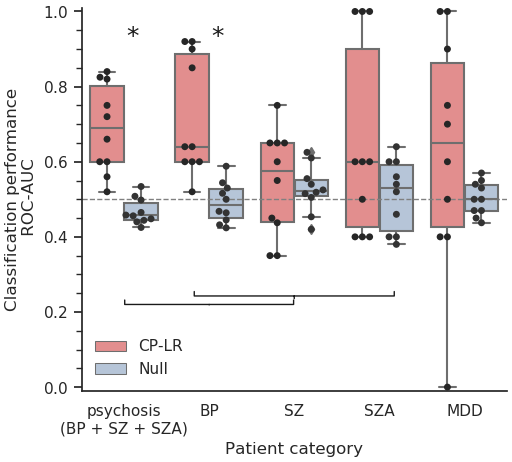

In [13]:
logreg_results=pd.concat(table_pval_ls).reset_index(drop=True)[['group','roc_auc','null_auc']].\
                    rename(columns={'roc_auc':'CP-LR','null_auc':'Null'});

logreg_results_melted=pd.melt(logreg_results, id_vars=['group'],\
                              value_vars=['CP-LR','Null']).rename(columns={'variable':'classifier','value':'ROC-AUC'})



plt.style.use(['science','no-latex','nature'])
custom_params = {"font.size":16,'xtick.bottom': True,'ytick.left': True}
sns.set_theme(style='white',rc=custom_params,font_scale=1)
# plt.rcParams['font.size'] = '16'
fig, axes = plt.subplots(1, 1, figsize=(5.5,5))
#         fig, axes = plt.subplots(len(rest_of_gmember_feats2), 1, figsize=(4, len(rest_of_gmember_feats2)*5))

orderC=["psychosis","BP","SZ","SZA","MDD"]
palette = ['lightcoral','lightsteelblue','lightcoral','firebrick','lightcoral','pink','lightgreen']

sns.boxplot(x="group", y='ROC-AUC', data=logreg_results_melted, hue='classifier',order=orderC,ax=axes,palette=palette)
sns.swarmplot(x="group", y='ROC-AUC', data=logreg_results_melted, hue='classifier',order=orderC,legend=False,dodge=True,\
              ax=axes, color=".2")
# axes.supxlabel('Year')

# fig.supylabel('Strength')
axes.set(ylabel='Classification performance\n ROC-AUC')
axes.set(xlabel='Patient category')
# axes.hlines(y=ln, xmin=-0.2, xmax=1, color="black")
axes.set_ylim([-0.01, 1.01])
axes.axhline(y=0.5,linewidth=1, color='grey',linestyle='--')
fs = 14.0
axes.annotate('', xy=(2, 0.25), xytext=(2, 0.228), fontsize=4, \
              arrowprops=dict(arrowstyle='-[, widthB=18.0, lengthB=0.8',color='k', lw=1.0))

axes.annotate('', xy=(1, 0.22), xytext=(1, 0.219), fontsize=4, \
              arrowprops=dict(arrowstyle='-[, widthB=15.2, lengthB=0.8',color='k', lw=1.0))

axes.text(0.1, 0.9, "*", ha='center', va='bottom', color='k', fontsize=18)  # Star
axes.text(1.1, 0.9, "*", ha='center', va='bottom', color='k', fontsize=18)  # Star
# axes.text(3.1, 0.9, "*", ha='center', va='bottom', color='k', fontsize=18)  # Star
axes.tick_params(axis='x', bottom=False)

# Remove legend title
legend = axes.get_legend()
legend.set_title("")

# Clean up spines and ticks
sns.despine(ax=axes, top=True, right=True)
axes.tick_params(axis='x', which='both', bottom=False, top=False)

# Custom x-axis labels
axes.set_xticklabels([
    "psychosis\n(BP + SZ + SZA)",  # updated label
    "BP",
    "SZ",
    "SZA",
    "MDD"
])

fig.tight_layout()
fig.savefig("../results/Figure3.pdf", bbox_inches="tight")

In [160]:
# fq_all_ds[fq_all_ds[fq_all_ds["features"].isin(final_features_to_use_for_VS)].isnull().max(axis=1)]

## Report Classification Performance (CP-LR versus CNN)
- Supplementary Figure 2.

/home/jupyter-mhaghigh@broadinst-ee45a/.local/lib/python3.7/site-packages/seaborn/categorical.py:166: FutureWarning: Setting a gradient palette using color= is deprecated and will be removed in version 0.13. Set `palette='dark:.2'` for same effect.
  warnings.warn(msg, FutureWarning)


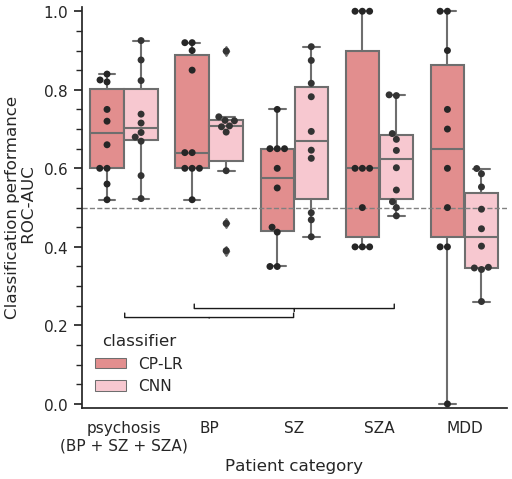

In [14]:
# %matplotlib widget
# Load the list
# with open('table_pval_ls.pkl', 'rb') as file:
#     table_pval_ls = pickle.load(file)
logreg_results=pd.concat(table_pval_ls).reset_index(drop=True)[['group','roc_auc']].rename(columns={'roc_auc':'CP-LR'})
# logreg_results['group'] = logreg_results['group'].replace('MDD or Dep','DEP')

# final auc for all k folds BP:  
BP_auc_ls=[0.8985372160826309, 0.7210214913425563, 0.7312030731622141, 0.705807092764119, 0.3903200167002122, 0.5938957214619782, 0.45968212498917704, 0.722077046835305, 0.6922448186348683, 0.708013408009809]
# final auc for all k folds Dep 
Dep_auc_ls=[0.5994753158698828, 0.5860629451467353, 0.3423604298617395, 0.3462297189137401, 0.49591034575913967, 0.26077571138371414, 0.44603453057219256, 0.5524965945267961, 0.40185182614489773, 0.3479176258738351]
# final auc for all k folds SZA 
SZA_auc_ls=[0.6014866360120785, 0.7852295185889547, 0.7871225613918122, 0.6455730476153638, 0.47899886916343776, 0.5149331527644363, 0.4999968629104411, 0.6738445892894702, 0.5447309021752711, 0.6885026688194275]
# final auc for all k folds SZ 
SZ_auc_ls=[0.9097696940860435, 0.6940000745795578, 0.6461828341032113, 0.8165253846451386, 0.4868552808281341, 0.8747876478276617, 0.4688405442473934, 0.6254893475036256, 0.4256557047073032, 0.7822706248673656]

psychosis_ls=[0.9253194012318833, 0.7379870977365104, 0.7153102528691841, 0.6796586618425476, 0.5229692106582183, 0.8759334204683245, 0.5813321839037189, 0.6912499435632977, 0.6690856087843747, 0.8234750622683167]

logreg_results.loc[logreg_results['group']=='psychosis','CNN']=psychosis_ls
logreg_results.loc[logreg_results['group']=='BP','CNN']=BP_auc_ls
logreg_results.loc[logreg_results['group']=='MDD','CNN']=Dep_auc_ls
logreg_results.loc[logreg_results['group']=='SZA','CNN']=SZA_auc_ls
logreg_results.loc[logreg_results['group']=='SZ','CNN']=SZ_auc_ls
logreg_results_melted=pd.melt(logreg_results, id_vars=['group'], value_vars=['CP-LR','CNN']).rename(columns={'variable':'classifier','value':'ROC-AUC'})
# custom_params = {"axes.spines.right": False, "axes.spines.top": False}
# sns.set_theme(style="ticks", rc=custom_params,font_scale=1)
plt.style.use(['science','no-latex','nature'])
custom_params = {"font.size":16,'xtick.bottom': True,'ytick.left': True}
sns.set_theme(style='white',rc=custom_params,font_scale=1)
# plt.rcParams['font.size'] = '16'
fig, axes = plt.subplots(1, 1, figsize=(5.5,5))
#         fig, axes = plt.subplots(len(rest_of_gmember_feats2), 1, figsize=(4, len(rest_of_gmember_feats2)*5))

orderC=["psychosis","BP","SZ","SZA","MDD"]
palette = ['lightcoral','pink','lightsteelblue','lightcoral','firebrick','lightcoral','pink','lightgreen']

sns.boxplot(x="group", y='ROC-AUC', data=logreg_results_melted, hue='classifier',order=orderC,ax=axes,palette=palette)
sns.swarmplot(x="group", y='ROC-AUC', data=logreg_results_melted, hue='classifier',order=orderC,legend=False,dodge=True,\
              ax=axes, color=".2")
# axes.supxlabel('Year')

# fig.supylabel('Strength')
axes.set(ylabel='Classification performance\n ROC-AUC')
axes.set(xlabel='Patient category')
axes.set_ylim([-0.01, 1.01])

# axes.hlines(y=ln, xmin=-0.2, xmax=1, color="black")
axes.axhline(y=0.5,linewidth=1, color='grey',linestyle='--')
fs = 14.0
# axes.annotate('', xy=(2, 0.25), xytext=(2, 0.228), fontsize=4, \
#               arrowprops=dict(arrowstyle='-[, widthB=18.0, lengthB=0.8',color='k', lw=1.0))

# axes.annotate('', xy=(1, 0.22), xytext=(1, 0.219), fontsize=4, \
#               arrowprops=dict(arrowstyle='-[, widthB=14.6, lengthB=0.8',color='k', lw=1.0))

axes.annotate('', xy=(2, 0.25), xytext=(2, 0.228), fontsize=4, \
              arrowprops=dict(arrowstyle='-[, widthB=18.0, lengthB=0.8',color='k', lw=1.0))

axes.annotate('', xy=(1, 0.22), xytext=(1, 0.219), fontsize=4, \
              arrowprops=dict(arrowstyle='-[, widthB=15.2, lengthB=0.8',color='k', lw=1.0))

fig.tight_layout()
# Clean up spines and ticks
sns.despine(ax=axes, top=True, right=True)
axes.tick_params(axis='x', which='both', bottom=False, top=False)

# Custom x-axis labels
axes.set_xticklabels([
    "psychosis\n(BP + SZ + SZA)",  # updated label
    "BP",
    "SZ",
    "SZA",
    "MDD"
])
fig.savefig("../results/SuppFigure2.pdf", bbox_inches="tight")

## Stats Check for Demographic Table

In [19]:

cols = ["subject","label", "Sex", "Age","D"]
df = df_1[cols].drop_duplicates()

df["Sex"] = (
    df["Sex"]
    .astype(str)
    .str.strip()
    .str.upper()
    .str[0]
)

df["Age"] = pd.to_numeric(df["Age"], errors="coerce")
df = df.dropna(subset=["label", "Sex", "Age"])

summary = (
    df.groupby("label", as_index=False)
      .agg(
          Age_min=("Age", "min"),
          Age_max=("Age", "max"),
          M_count=("Sex", lambda s: (s == "M").sum()),
          F_count=("Sex", lambda s: (s == "F").sum()),
      )
      .sort_values("label", kind="stable")
)

summary["Age_range"] = summary.apply(
    lambda r: f"{int(r.Age_min)}–{int(r.Age_max)}", axis=1
)
summary

,label,Age_min,Age_max,M_count,F_count,Age_range
0,BP,19,69,36,14,19–69
1,Control,20,65,31,17,20–65
2,MDD,18,55,10,10,18–55
3,SZ,18,68,32,7,18–68
4,SZA,19,45,7,4,19–45


In [20]:
39+11

50

In [56]:
summary

,label,Age_min,Age_max,M_count,F_count,Age_range
0,BP,19,69,36,14,19–69
1,Control,20,65,30,17,20–65
2,MDD,18,55,11,10,18–55
3,SZ,18,68,32,7,18–68
4,SZA,20,45,7,4,20–45


In [60]:
df.groupby(['label', 'D']).size()

label    D                                     
BP       BP                                        14
         BP w/ psychosis                            1
         BP-B                                       2
         BPI                                       31
         BPI-B                                      1
         BPII                                       1
Control  Control                                   47
MDD      Dep                                        8
         Dep w/ psychosis                           1
         MDD                                        9
         MDD w psychosis                            1
         MDD w/ psychosis                           1
         MDD w/ psychosis & Schizophreniform DO     1
SZ       SZ                                        35
         SZ, MDD 2ºdx                               1
         SZ, paranoid type                          1
         SZ, undifferentiated                       2
SZA      SZA                      

In [35]:
df_1['subject'].unique().shape

(168,)

In [61]:
df[df['label']=='SZA']

,subject,label,Sex,Age,D
7986,179,SZA,F,29,"SZA, bipolar type"
9441,194,SZA,M,33,"SZA, bipolar type"
12384,239,SZA,F,20,"SZA, dep type"
14965,263,SZA,M,45,"SZA, dep type"
16732,272,SZA,M,42,"SZA, bipolar type"
16943,274,SZA,F,25,"SZA, dep"
30681,73,SZA,M,44,"SZA, bipolar type"
35658,MCL102,SZA,M,22,SZA
35927,MCL103,SZA,M,41,SZA
37322,MCL114,SZA,M,27,SZA


In [41]:
116+51

167

In [45]:
df_1['Sex'].unique()

array(['F', 'M', nan], dtype=object)

In [16]:
# df_1[df_1['Sex'].isnull()]

In [50]:
disease_labels=pd.read_excel(home_path+"bucket/projects/2016_08_01_RadialMitochondriaDistribution_donna/\
workspace/metadata/patient_labels_updatedSept302025.xlsx")

In [17]:
# disease_labels